# Predictions for Remdesivir are within observed values and indicate Remdesivir as a good antiviral agent and Molnuparavir as good but less effective

Ebola(all) observed mean ± SD: 7.295 ± 0.490


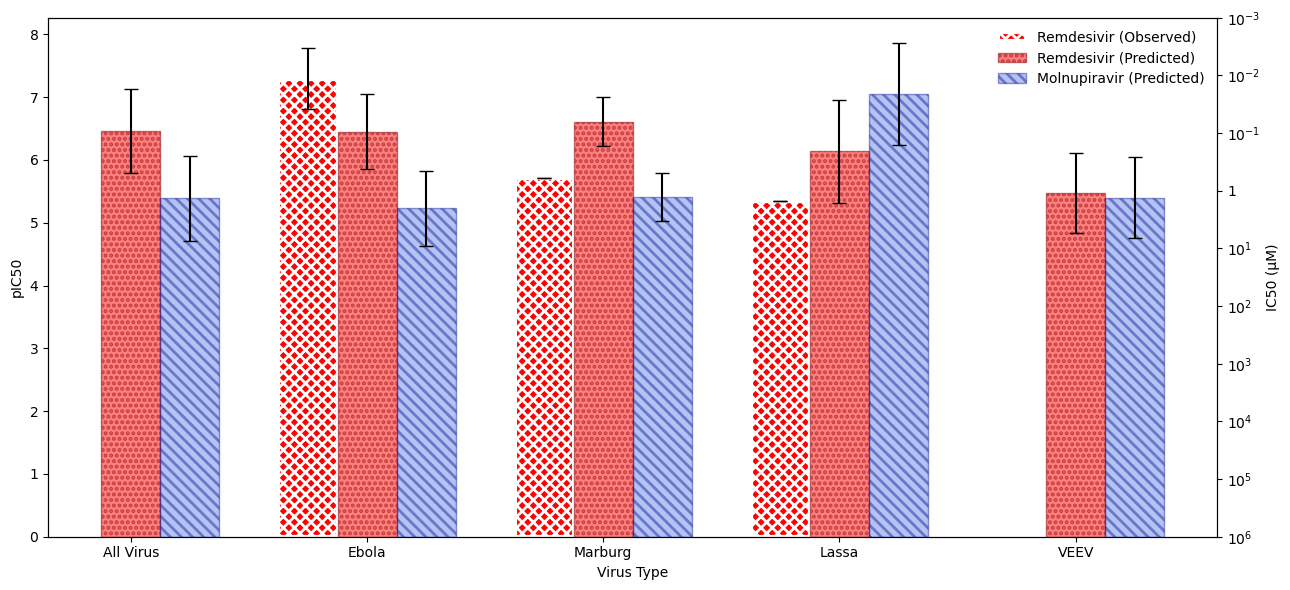

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 2
mpl.rcParams['hatch.color'] = 'white'
#mpl.rcParams['hatch.spacing'] = 8.0

# New detailed Ebola(all) observed values
ebola_all_vals = np.array([7.07, 6.85, 6.89, 7.22, 7.15, 7.18, 7.68, 7.85, 8.52, 7.11, 6.87, 7.15], dtype=float)
ebola_all_mean = ebola_all_vals.mean()
ebola_all_std  = ebola_all_vals.std(ddof=1)

# Remove 'Zaire Ebola' entirely
data = {
    'Drug Name': ['Remdesivir (Observed)', 'Remdesivir (Predicted)', 'Molnupiravir (Predicted)'],
    'All Virus': [np.nan, 6.46, 5.39],
    'Ebola': [ebola_all_mean, 6.45, 5.23],   # observed = new mean
    'Marburg': [5.72, 6.61, 5.41],
    'Lassa': [5.35, 6.14, 7.05],
    'VEEV': [np.nan, 5.47, 5.40]
}

pred_errors = {
    'Drug Name': ['Remdesivir (Predicted)', 'Molnupiravir (Predicted)'],
    'All Virus': [0.674, 0.674],
    'Ebola': [0.596, 0.596],
    'Marburg': [0.387, 0.380],
    'Lassa': [0.819, 0.820],
    'VEEV': [0.638, 0.639]
}

lit_errors = {
    'All Virus': np.nan,
    'Ebola': ebola_all_std,   # observed error = SD from replicate list
    'Marburg': 0.0,
    'Lassa': 0.0,
    'VEEV': np.nan
}

df_pic50 = pd.DataFrame(data)
df_errors = pd.DataFrame(pred_errors)

viruses = ['All Virus', 'Ebola', 'Marburg', 'Lassa', 'VEEV']
x = np.arange(len(viruses))
width = 0.25

rem_lit  = df_pic50.loc[0, viruses].values
rem_pred = df_pic50.loc[1, viruses].values
mol_pred = df_pic50.loc[2, viruses].values

rem_err = df_errors.loc[0, viruses].values
mol_err = df_errors.loc[1, viruses].values
rem_lit_err = np.array([lit_errors[v] if not np.isnan(rem_lit[i]) else 0.0 for i, v in enumerate(viruses)])

def pic50_to_ic50(pic50): return 10**(-pic50) * 1e6
def format_ic50(v):
    if v == 0: return '$0$'
    exp = int(np.floor(np.log10(abs(v))))
    man = v / (10**exp)
    if exp == 0: return f'${man:.2g}$'
    if abs(man - 1.0) < 0.01: return f'$10^{{{exp}}}$'
    return f'${man:.2f} \\times 10^{{{exp}}}$'

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(x - width, rem_lit, width, yerr=rem_lit_err, capsize=5,
        label='Remdesivir (Observed)', alpha=1, hatch='xxx',
        color='red', edgecolor='white', linewidth=3)

ax1.bar(x, rem_pred, width, yerr=rem_err, capsize=5,
        label='Remdesivir (Predicted)', alpha=0.5, hatch='...',
        color='red', edgecolor='darkred', linewidth=1.0)

ax1.bar(x + width, mol_pred, width, yerr=mol_err, capsize=5,
        label='Molnupiravir (Predicted)', alpha=0.4, hatch='\\\\\\',
        color='royalblue', edgecolor='darkblue', linewidth=1.0)

ax1.set_xlabel('Virus Type')
ax1.set_ylabel('pIC50')
ax1.set_xticks(x)
ax1.set_xticklabels(viruses)
#ax1.set_title('Antiviral Potency: pIC50 Values')
ax1.legend(loc='upper right', frameon=False)

# Secondary axis: IC50 (µM)
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ticks = ax1.get_yticks()
ax2.set_yticks(ticks)
ax2.set_yticklabels([format_ic50(pic50_to_ic50(t)) for t in ticks])
ax2.set_ylabel('IC50 (µM)')

print(f"Ebola(all) observed mean ± SD: {ebola_all_mean:.3f} ± {ebola_all_std:.3f}")

plt.tight_layout()
plt.savefig('antiviral_potency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()